In [ ]:
#!git clone https://github.com/CharFraza/CPC_ML_tutorial.git
!git clone --branch 2026 https://github.com/CharFraza/CPC_ML_tutorial.git

## Estimating lifespan normative models
This notebook provides a complete walkthrough of a normative modelling analysis using your own dataset. Training and testing datasets are provided for the purposes of this tutorial. However, you can easily substitute these with your own datasets, provided they follow the same format.

First, if necessary, we install PCNtoolkit.

The latest version of PCNtoolkit includes several updates and new features compared with previous versions. If you have used normative modelling before, we recommend familiarising yourself with the updated syntax and functionality.

For a deeper dive into the theoretical background, see the [protocol update](https://www.biorxiv.org/content/10.64898/2026.02.17.706268v2.full).

<img src="/home/preclineu/chafra/Desktop/code_postdoc/CPC_ML_tutorial/images/main_protocol.png" alt="Protocol Normative Models" width="500">


In [20]:
# %%
%%capture
!pip install pcntoolkit

In this tutorial, you are going to fit a normative model (or brain growth chart) from scratch. Usually, we do not recommend doing this unless you have the computational resources needed to analyse 100,000 images. In the second tutorial, we will show you a much more appropriate technique using federated learning, so that you can easily apply the models to your own dataset. But let's get started!

### Some household notes
* Make sure you read all the text. It is easy to click and play, but answering the questions is where the real learning happens.
* Try playing around with different parameter settings and variables to make sure you really understand what is happening.
* If you are an advanced user, consider adapting the methods to your own data. You can download the tutorials locally to avoid having your data on a Google server ;)


In [11]:
# Import all the required libraries
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from pcntoolkit import (
    BLR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    plot_centiles,
    plot_centiles_advanced,
    plot_qq,
    plot_ridge,
)

Now, we configure the locations in which the data are stored.

**Notes:**
- The data are assumed to be in .CSV format and will be loaded as pandas dataframes
- Generally the raw data will be in a different location to the analysis
- The data can have several columns/covariates but some are required by the script, i.e. 'age', 'sex' and 'site', plus the phenotypes you wish to estimate

In [18]:
# where the raw data are stored

# where the analysis takes place
root_dir = '/content/CPC_ML_tutorial/CPC_ML_tutorial'
!cd '/content/CPC_ML_tutorial/CPC_ML_tutorial'

data_dir = os.path.join(root_dir, 'data')

out_dir = os.path.join(root_dir, 'models', 'test')

# create the output directory if it does not already exist
os.makedirs(out_dir, exist_ok=True)

## Load the data
Now we load the data.
We will load one pandas dataframe for the training set and one dataframe
for the test set. We also configure a list of site ids.


In [19]:
df_tr = pd.read_csv(
    os.path.join(data_dir, 'train_data.csv'),
    index_col=0
)

df_te = pd.read_csv(
    os.path.join(data_dir, 'test_data.csv'),
    index_col=0
)

# extract a list of unique site ids from the training set
site_ids = sorted(set(df_tr['site'].to_list()))

print(site_ids)

['cam', 'hcp', 'ixi']


### Configure which models to fit

Next, we load the image derived phenotypes (IDPs) which we will process in this analysis. This is effectively just a list of columns in your dataframe. Here we estimate normative models for the left hemisphere, right hemisphere and cortical structures.

In [24]:
# we choose here to process all idps. Uncomment lines 2-7 (and comment line 11) to run models for the whole brain, but we suggest just starting with several ROIs
#os.chdir(root_dir)
#!wget -nc https://raw.githubusercontent.com/CharFraza/CPC_ML_tutorial/master/data/task1_phenotypes.txt
#with open(os.path.join(root_dir,'task1_phenotypes.txt')) as f:
#  idp_ids = f.read().splitlines()
#for idx, ele in enumerate(idp_ids):
#        idp_ids[idx] = ele.replace('\t', '')

# we could also just specify a list of IDPs. Use this line to run just 2 models (not the whole brain)...this is a good place to start. If you have time,
# you can uncomment the above line and run the whole brain models. Be sure to comment out this line if you uncomment the above line.
idp_ids = ['lh_MeanThickness_thickness', 'rh_MeanThickness_thickness']

In [25]:
# Pandas can give us a quick summary of the numerical variables,
# including the number of observations, mean, standard deviation,
# minimum and maximum values.
# Make sure you understand what each variable represents in the context of your study!
df_tr.describe()
df_te.describe()

,age,sex,lh_bankssts_thickness,lh_caudalanteriorcingulate_thickness,lh_caudalmiddlefrontal_thickness,lh_cuneus_thickness,lh_entorhinal_thickness,lh_fusiform_thickness,lh_inferiorparietal_thickness,lh_inferiortemporal_thickness,...,rh_rostralmiddlefrontal_thickness,rh_superiorfrontal_thickness,rh_superiorparietal_thickness,rh_superiortemporal_thickness,rh_supramarginal_thickness,rh_frontalpole_thickness,rh_temporalpole_thickness,rh_transversetemporal_thickness,rh_insula_thickness,rh_MeanThickness_thickness
count,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,...,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000
mean,40.985825,1.582474,2.631909,2.694679,2.672064,1.970139,3.418003,2.860746,2.541505,2.936792,...,2.507351,2.806170,2.260490,2.873667,2.630435,2.850584,3.727763,2.513985,3.039560,2.583761
std,17.421706,0.493575,0.171774,0.210494,0.175930,0.180919,0.278445,0.134743,0.138928,0.140404,...,0.156215,0.165626,0.153648,0.176432,0.168295,0.241382,0.333725,0.330905,0.178789,0.123254
min,18.000000,1.000000,1.526000,1.861000,1.394000,1.121000,2.547000,1.987000,1.536000,2.271000,...,1.746000,1.640000,1.270000,1.807000,1.694000,1.997000,2.518000,0.962000,1.802000,1.681110
25%,28.000000,1.000000,2.536750,2.560000,2.576000,1.846750,3.232250,2.787000,2.461500,2.846000,...,2.399250,2.704250,2.171000,2.778250,2.527500,2.693250,3.528250,2.327750,2.941750,2.508243
50%,33.000000,2.000000,2.638000,2.690000,2.681500,1.988000,3.401500,2.856500,2.544000,2.925000,...,2.506500,2.812000,2.277000,2.892500,2.649000,2.852000,3.758500,2.572000,3.041500,2.589895
75%,54.666667,2.000000,2.740000,2.825750,2.775500,2.098750,3.603000,2.946000,2.624000,3.019750,...,2.611000,2.910000,2.362000,2.995750,2.731500,3.007500,3.954000,2.752000,3.144750,2.660048
max,88.000000,2.000000,3.190000,3.430000,3.177000,2.392000,4.541000,3.277000,2.990000,3.521000,...,2.966000,3.279000,2.631000,3.302000,3.095000,3.722000,4.477000,3.389000,3.691000,2.897700


,age,sex,site,lh_bankssts_thickness,lh_caudalanteriorcingulate_thickness,lh_caudalmiddlefrontal_thickness,lh_cuneus_thickness,lh_entorhinal_thickness,lh_fusiform_thickness,lh_inferiorparietal_thickness,...,rh_rostralmiddlefrontal_thickness,rh_superiorfrontal_thickness,rh_superiorparietal_thickness,rh_superiortemporal_thickness,rh_supramarginal_thickness,rh_frontalpole_thickness,rh_temporalpole_thickness,rh_transversetemporal_thickness,rh_insula_thickness,rh_MeanThickness_thickness
participant_id,,,,,,,,,,,,,,,,,,,,,
sub-CC620785,69.0,1,cam,2.653,2.379,2.711,2.336,3.628,2.813,2.637,...,2.383,2.672,2.447,2.716,2.580,2.507,4.001,2.465,2.919,2.56867
sub-298455,24.0,1,hcp,2.692,2.582,2.756,1.928,3.790,2.873,2.508,...,2.621,2.903,2.281,3.060,2.682,3.006,3.758,2.785,3.271,2.62406
sub-CC510076,62.0,1,cam,2.347,2.324,2.495,2.037,2.998,2.717,2.565,...,2.339,2.631,2.230,2.791,2.562,2.905,3.629,2.404,2.840,2.48958
sub-181636,33.0,2,hcp,2.723,2.684,2.724,2.045,2.978,2.838,2.391,...,2.615,2.886,2.245,2.761,2.617,2.895,3.745,2.655,3.081,2.58602
sub-356948,29.0,2,hcp,2.544,2.613,2.762,2.038,3.297,2.759,2.520,...,2.537,2.889,2.232,2.697,2.685,2.946,3.344,2.759,2.781,2.57703


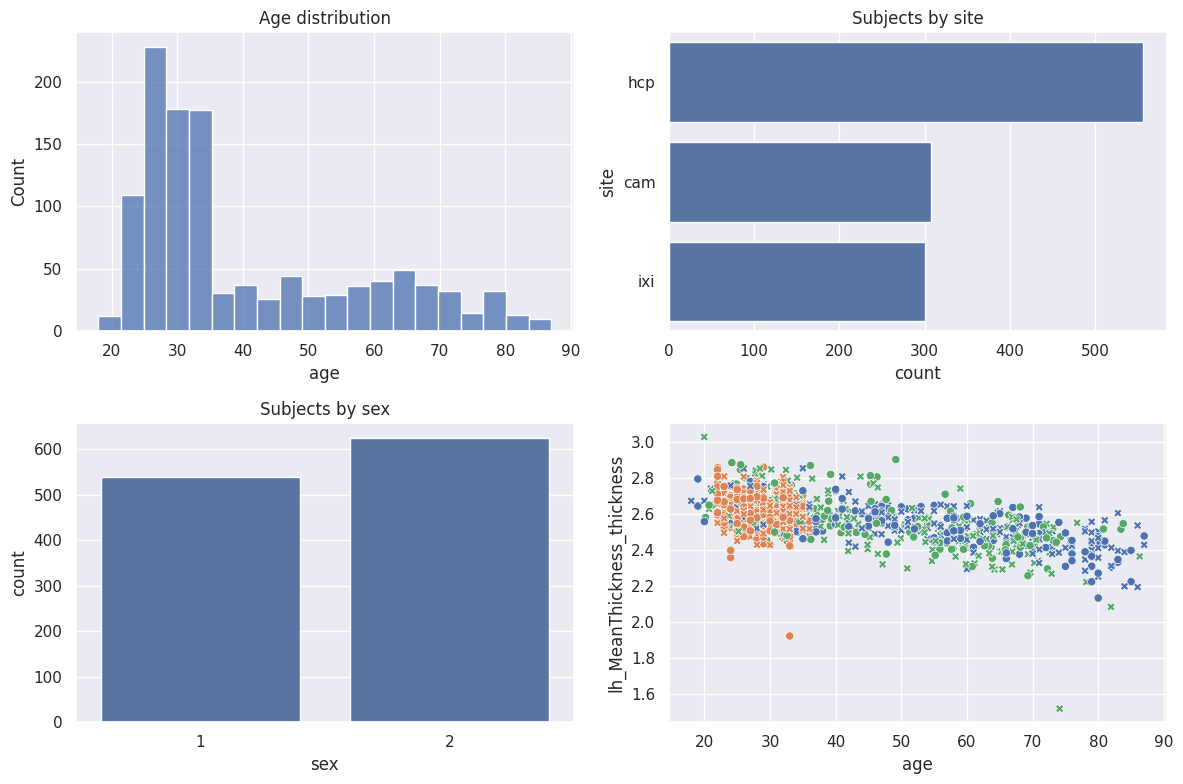

In [26]:
# Explore the data a little further and make sure you understand what each variable represents.
# Compare the values also to df_te to see if the distributions are similar between the training and test sets.
display(df_tr.head())

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df_tr, x='age', bins=20, ax=ax[0, 0])
ax[0, 0].set_title('Age distribution')

sns.countplot(
    data=df_tr,
    y='site',
    order=df_tr['site'].value_counts().index,
    ax=ax[0, 1]
)
ax[0, 1].set_title('Subjects by site')

sns.countplot(data=df_tr, x='sex', ax=ax[1, 0])
ax[1, 0].set_title('Subjects by sex')

sns.scatterplot(
    data=df_tr,
    x='age',
    y=idp_ids[0], # Change this to the IDP you want to plot
    hue='site',
    style='sex',
    legend=False,
    ax=ax[1, 1]
)

plt.tight_layout()
plt.show()

### Covariates, batch effects and response variable selection
In general, the choice of covariates and batch effects depends on your research question. However, age, sex, and site are commonly recommended starting points for normative modelling:
- Batch effects allow your model to account for systematic differences between groups or participants. For example, when people are scanned at different sites or using different scanners, differences may appear in the data because of the site or scanner rather than genuine biological differences. Batch effects allow the model to account for these systematic differences. They can be used for variables such as site, scanner, sex, ancestry, or imaging field strength, depending on the application. For a more detailed explanation of batch effects and partial pooling in normative modelling, see the [protocol update](https://www.biorxiv.org/content/10.64898/2026.02.17.706268v2.full).
- Covariates are variables that the model uses to explain variation in the response variable. They are typically continuous variables, such as age or height. In normative modelling, covariates are often variables that we expect to be related to the biological measure we are modelling. For example, a model might predict brain volume (the response variable) based on age (the covariate), while accounting for differences between sex and scanning sites using batch effects.

Note: If you are interested in understanding how sex affects the outcome, it may make more sense to treat sex as a covariate rather than simply as a batch effect :)

In [27]:
cols_cov = ['age']
batch_effects = ['sex', 'site']

## Configure model parameters
We now configure parameters for the regression model used to fit the normative model. Specifically, we use a warped Bayesian linear regression model, applying a SinhArcsinh warp to handle non-Gaussianity. To capture non-linearity, we use the default cubic B-spline basis with five knot points, which requires no additional parameters. However, we do specify age range limits, padding a few years beyond the observed range. Finally, we set a few options that govern the model estimation process.
or further details about the likelihood warping approach, see [Fraza et al 2021](https://www.sciencedirect.com/science/article/pii/S1053811921009873?via%3Dihub).
For more details on B-spline expansions, see: https://www.geeksforgeeks.org/data-analysis/b-splines-using-scipy/

In [28]:
# which warping function to use? We can set this to None in order to fit a vanilla Gaussian noise model
use_warp = True
wrap_function = 'warpsinharcsinh'

basis_function = BsplineBasisFunction(
    degree=3,
    nknots=5
)

# Do we want to force the model to be refit every time?
# When training normative model from scratch like we are doing in this notebook (not re-using a pre-trained model),
# this variable should be = True
force_refit = True

# Absolute Z treshold above which a sample is considered to be an outlier (without fitting any model)
outlier_thresh = 7

# Data preparation
In the PCNtoolkit the NormData class is used for general data cleaning, harmonization, and preparation.
Check some of the outputs carefully, are the batch_effects set up right, what are your response variables? Etc.

In [29]:
response_vars = idp_ids

norm_train = NormData.from_dataframe(
    name='train',
    dataframe=df_tr,
    covariates=cols_cov,
    batch_effects=batch_effects,
    response_vars=response_vars
)

norm_test = NormData.from_dataframe(
    name='test',
    dataframe=df_te,
    covariates=cols_cov,
    batch_effects=batch_effects,
    response_vars=response_vars
)

print(norm_train)
print(norm_test)

Process: 525 - 2026-08-13 13:24:22 - Dataset "train" created.
    - 1163 observations
    - 1163 unique subjects
    - 1 covariates
    - 2 response variables
    - 2 batch effects:
    	sex (2)
	site (3)
    
Process: 525 - 2026-08-13 13:24:22 - Dataset "test" created.
    - 582 observations
    - 582 unique subjects
    - 1 covariates
    - 2 response variables
    - 2 batch effects:
    	sex (2)
	site (3)
    
<xarray.NormData> Size: 75kB
Dimensions:            (observations: 1163, response_vars: 2, covariates: 1,
                        batch_effect_dims: 2)
Coordinates:
  * observations       (observations) int64 9kB 0 1 2 3 ... 1159 1160 1161 1162
  * response_vars      (response_vars) <U26 208B 'lh_MeanThickness_thickness'...
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
Data variables:
    subject_ids        (observations) int64 9kB 0 1 2 3 ... 1159 1160 1161 1162
    Y                  (observations, response_

## Model settup
Here we define the settings for our BLR normative model, using the B-spline for non-linear relationships, allowing variance to change with age (heteroskedastic) and setting the fixed effects to account for batch_effects, allowing differences between sites/groups to influence the mean and variance of the model.
Finally a sinh-arcsinh warping is used to handle non-Gaussian residuals.
Play around with the settings and see how your model changes~

In [30]:
blr_kwargs = {
    'name': 'lifespan_blr',

    # cubic B-spline basis with 5 knots as selected before
    'basis_function_mean': basis_function,

    # allow the variance to depend on the covariates, in this case age
    'heteroskedastic': True,

    # model the batch effects
    'fixed_effect': True,
    'fixed_effect_slope': True,
    'fixed_effect_var_slope': True,
}

# optionally add Sinh-Arcsinh warping to adress non-Gaussian noise in the data. This is a flexible warping function that can model skewness and heavy tails in the distribution of the residuals.
if use_warp:
    blr_kwargs['warp_name'] = wrap_function

# %%
blr = BLR(
    **blr_kwargs
)

model = NormativeModel(
    template_regression_model=blr,
    savemodel=True,
    evaluate_model=True,
    saveresults=True,
    saveplots=True,
    save_dir=out_dir,
    inscaler='standardize',
    outscaler='standardize',
)

### Fit the models

Now we fit the models. This involves looping over the IDPs we have selected.

In [31]:
model.fit_predict(
    norm_train,
    norm_test
)

Process: 525 - 2026-08-13 13:24:28 - Fitting models on 2 response variables.
Process: 525 - 2026-08-13 13:24:28 - Fitting model for lh_MeanThickness_thickness.


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14373e-148): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/pcntoolkit/util/output.py:296: UserWarning: Process: 525 - 2026-08-13 13:24:29 - Posterior estimation failed: 
Matrix is not positive definite. 
The optimizer could not find a stable solution. Retrying optimization.
  warnings.warn(message, category)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.66633e-148): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.93972e-148): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.66635

Process: 525 - 2026-08-13 13:24:29 - Fitting model for rh_MeanThickness_thickness.


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.0113e-121): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/pcntoolkit/util/output.py:296: UserWarning: Process: 525 - 2026-08-13 13:24:30 - Posterior estimation failed: 
Matrix is not positive definite. 
The optimizer could not find a stable solution. Retrying optimization.
  warnings.warn(message, category)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.58666e-121): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.43925e-121): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.60291e

Process: 525 - 2026-08-13 13:24:30 - Saving model to:
	/content/CPC_ML_tutorial/CPC_ML_tutorial/models/test.
Process: 525 - 2026-08-13 13:24:30 - Making predictions on 2 response variables.
Process: 525 - 2026-08-13 13:24:30 - Computing z-scores for 2 response variables.
Process: 525 - 2026-08-13 13:24:30 - Computing z-scores for lh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:24:30 - Computing z-scores for rh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:24:30 - Computing centiles for 2 response variables.
Process: 525 - 2026-08-13 13:24:30 - Computing centiles for lh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:24:30 - Computing centiles for rh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:24:30 - Computing log-probabilities for 2 response variables.
Process: 525 - 2026-08-13 13:24:30 - Computing log-probabilities for 2 response variables.
Process: 525 - 2026-08-13 13:24:30 - Computing log-probabilities for lh_MeanThickness_thickness.
Process: 525 - 

/usr/local/lib/python3.12/dist-packages/pcntoolkit/dataio/norm_data.py:1213: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  subject_ids = subject_ids.stack(level="centile")


Process: 525 - 2026-08-13 13:24:32 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 2 response variables
    - 2 batch effects:
    	sex (1)
	site (1)
    
Process: 525 - 2026-08-13 13:24:32 - Computing centiles for 2 response variables.
Process: 525 - 2026-08-13 13:24:32 - Computing centiles for lh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:24:32 - Computing centiles for rh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:24:32 - Harmonizing data on 2 response variables.
Process: 525 - 2026-08-13 13:24:32 - Harmonizing data for lh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:24:32 - Harmonizing data for rh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:24:33 - Making predictions on 2 response variables.
Process: 525 - 2026-08-13 13:24:33 - Computing z-scores for 2 response variables.
Process: 525 - 2026-08-13 13:24:33 - Computing z-scores for lh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:2

/usr/local/lib/python3.12/dist-packages/pcntoolkit/dataio/norm_data.py:1213: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  subject_ids = subject_ids.stack(level="centile")


Process: 525 - 2026-08-13 13:24:34 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 2 response variables
    - 2 batch effects:
    	sex (1)
	site (1)
    
Process: 525 - 2026-08-13 13:24:34 - Computing centiles for 2 response variables.
Process: 525 - 2026-08-13 13:24:34 - Computing centiles for lh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:24:34 - Computing centiles for rh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:24:34 - Harmonizing data on 2 response variables.
Process: 525 - 2026-08-13 13:24:34 - Harmonizing data for lh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:24:34 - Harmonizing data for rh_MeanThickness_thickness.


<xarray.NormData> Size: 122kB
Dimensions:            (observations: 582, response_vars: 2, covariates: 1,
                        batch_effect_dims: 2, centile: 5, statistic: 13)
Coordinates:
  * observations       (observations) int64 5kB 0 1 2 3 4 ... 578 579 580 581
  * response_vars      (response_vars) <U26 208B 'lh_MeanThickness_thickness'...
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
  * statistic          (statistic) <U8 416B 'EXPV' 'Kurtosis' ... 'Skewness'
Data variables:
    subject_ids        (observations) int64 5kB 0 1 2 3 4 ... 578 579 580 581
    Y                  (observations, response_vars) float64 9kB 2.593 ... 2.448
    X                  (observations, covariates) float64 5kB 80.17 ... 73.0
    batch_effects      (observations, batch_effect_dims) <U3 14kB '2' ... 'cam'
    Z                  (observations, response_vars) float64 9kB 1.867 ... -0...
    centiles           (centile, observations, response_vars) float64 47kB 1....
    baseline_logp      (observations, response_vars) float64 9kB -0.8923 ... ...
    logp               (observations, response_vars) float64 9kB -2.327 ... -...
    Yhat               (observations, response_vars) float64 9kB 2.303 ... 2.437
    statistics         (response_vars, statistic) float64 208B 0.2724 ... 0.1428
Attributes:
    real_ids:                       False
    is_scaled:                      False
    name:                           test
    unique_batch_effects:           {np.str_('sex'): ['2', '1'], np.str_('sit...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'min': 18.0, 'max': 88.0}}
    batch_effect_covariate_ranges:  {np.str_('sex'): {'2': {np.str_('age'): {...

## Explore and visualize the normative model
We can now get to the fun part of visualizing our normative models, using centile curves and QQ-plots.

Process: 525 - 2026-08-13 13:24:35 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 2 response variables
    - 2 batch effects:
    	sex (1)
	site (1)
    
Process: 525 - 2026-08-13 13:24:35 - Computing centiles for 2 response variables.
Process: 525 - 2026-08-13 13:24:35 - Computing centiles for lh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:24:35 - Computing centiles for rh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:24:35 - Harmonizing data on 2 response variables.
Process: 525 - 2026-08-13 13:24:35 - Harmonizing data for lh_MeanThickness_thickness.
Process: 525 - 2026-08-13 13:24:35 - Harmonizing data for rh_MeanThickness_thickness.


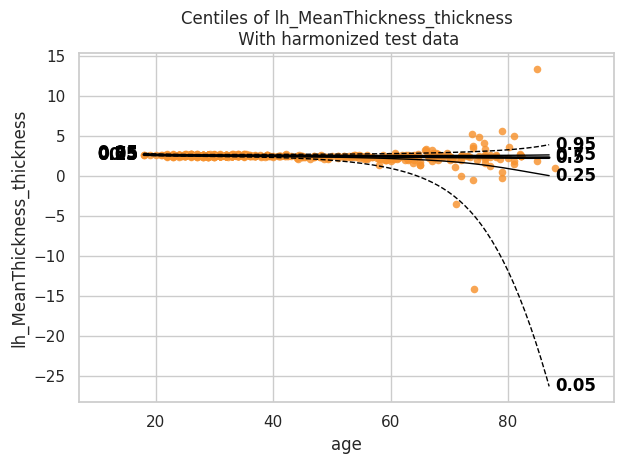

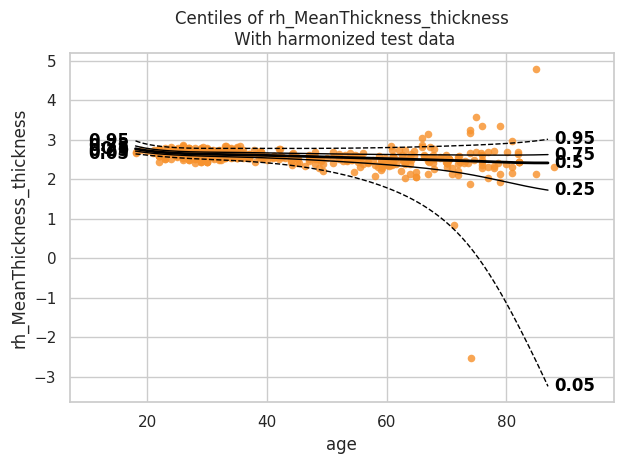

[<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>]

In [32]:
# These centile plots show the expected distribution of the response variable across the range of the covariate (e.g., age), similar to a growth chart.
# The shaded areas represent the 5th, 25th, 50th, 75th, and 95th percentiles of the expected distribution,
# while the scatter points represent the actual data points from the test set.
# This allows us to visually assess how well the model captures the variability in the data and whether there are any systematic deviations from the expected distribution.
plot_centiles(
    model,
    scatter_data=norm_test
)

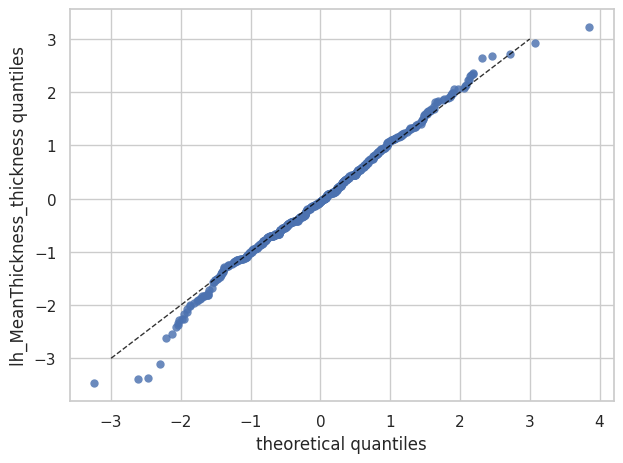

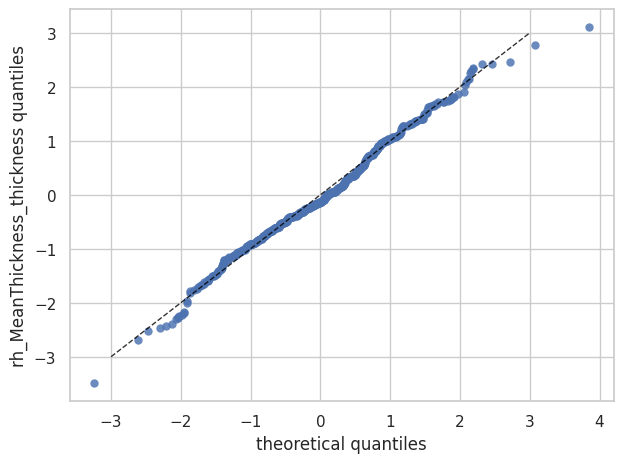

[<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>]

In [33]:
# Checking model fit with a Q–Q plot
# A Q–Q plot (quantile-quantile plot) is a graphical tool to assess if a dataset follows a particular theoretical distribution,
# in this case, the normal distribution, see if the line follows the 45-degree line,
# which would indicate that the data follows a normal distribution.
plot_qq(
    norm_test,
    plot_id_line=True
)

### Compute error metrics

In this section we show the following error metrics for all IDPs (all evaluated on the test set): assess the goodness of fit between the predicted probabilities of a model and the actual observed outcomes.
- Negative log likelihood (NLL): NLL assesses the goodness of fit between the predicted probabilities of a model and the actual observed outcomes. In this case, it measures the discrepancy between the predicted probabilities of the model for the IDPs (Independent Data Points) and the actual outcomes on the test set.
- Explained variance (EV): EV assesses how much of the total variation in the dependent variable (IDP) is explained by the independent variables. In the context of this analysis, it quantifies the extent to which the independent variables account for the variability observed in the IDPs on the test set.
- Mean standardized log loss (MSLL): MSLL takes into account both the mean error and the estimated prediction variance. It is used to evaluate the performance of the model, and in this case, a lower MSLL indicates a better-fitting model for the IDPs on the test set.
- Bayesian information criteria (BIC): BIC is a model selection criterion that balances the goodness of fit to the data with the model's complexity. It penalizes models with higher flexibility and aims to find the best trade-off. Lower BIC scores indicate models that better explain the IDPs on the test set while considering the model complexity.
- Skew and Kurtosis of the Z-distribution: Skewness and kurtosis are statistical measures used to assess the shape and characteristics of a distribution. They provide information about how well the warping function performed in terms of capturing the departure from a normal distribution for the IDPs.

For more information on the different model selection criteria see [Fraza et al 2021](https://www.biorxiv.org/content/10.1101/2021.04.05.438429v1)

In [34]:
# Evaluating model performance
train_metrics = norm_train.get_statistics_df()
test_metrics = norm_test.get_statistics_df()


# We can also look at a set of summary statistics to evaluate how well the normative model performs on both the training and test datasets.
print("Training set metrics:")
display(train_metrics)


#
print("Test set metrics:")
display(test_metrics)

Training set metrics:


statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
lh_MeanThickness_thickness,0.393104,0.025640,0.032330,0.027737,1.138772,-0.280166,0.392343,0.093822,0.587174,1.036202e-108,0.607657,0.996701,-0.007630
rh_MeanThickness_thickness,0.443823,0.063664,0.034481,0.028602,1.107935,-0.311003,0.442789,0.095192,0.633873,1.067779e-131,0.557211,0.996392,-0.027962


Test set metrics:


statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
lh_MeanThickness_thickness,0.272362,0.432754,0.050674,0.028969,1.189728,-0.189279,0.272259,0.098656,0.534382,2.752604e-44,0.727741,0.995534,0.014312
rh_MeanThickness_thickness,0.387920,0.314183,0.045425,0.028262,1.130335,-0.253692,0.387845,0.096352,0.623073,6.869341e-64,0.612155,0.993190,0.142791


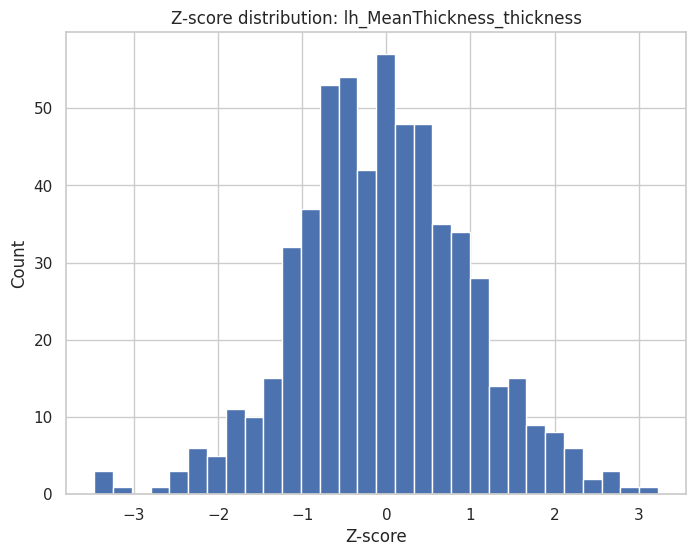

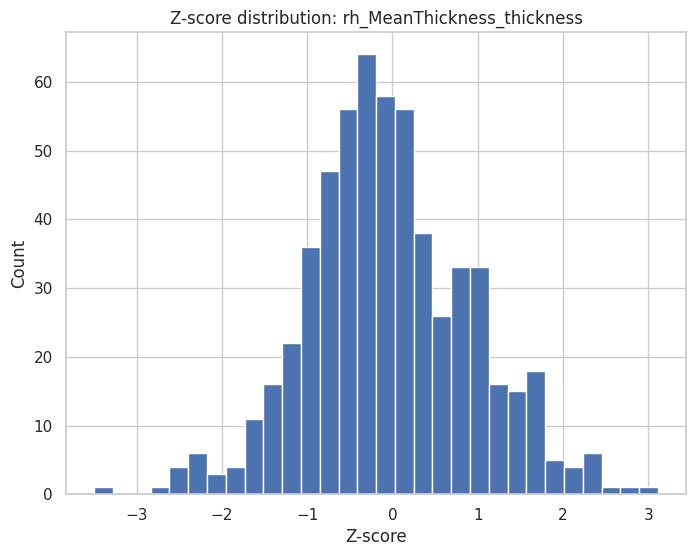

In [35]:
for idp in idp_ids:

    z = norm_test['Z'].sel(
        response_vars=idp
    ).values

    plt.figure(
        figsize=(8, 6)
    )

    plt.hist(
        z,
        bins=30
    )

    plt.xlabel('Z-score')
    plt.ylabel('Count')

    plt.title(
        f'Z-score distribution: {idp}'
    )

    plt.show()


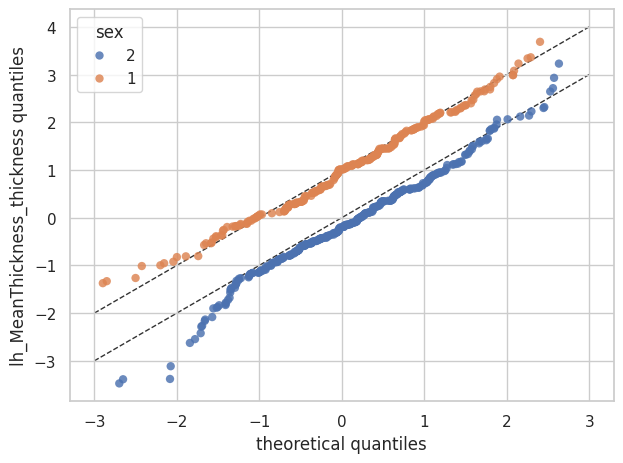

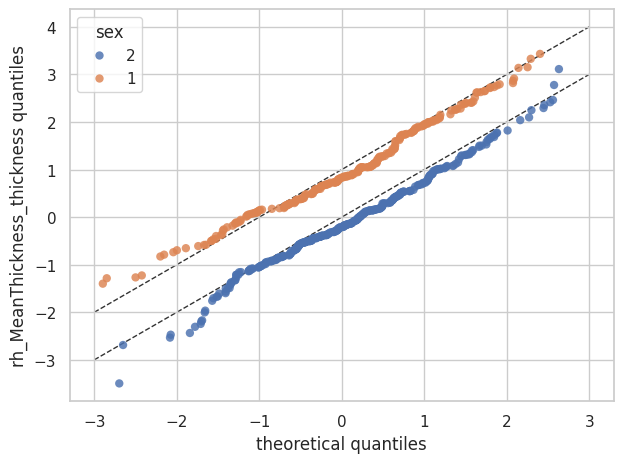

[<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>]

In [36]:
plot_qq(
    norm_test,
    plot_id_line=True,
    hue_data='sex',
    split_data='sex'
)

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/s

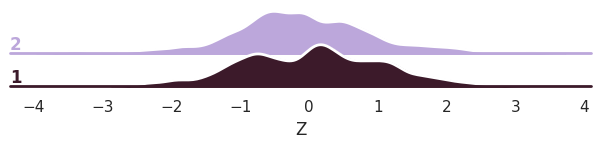

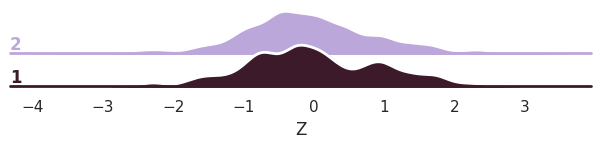

[<Figure size 750x100 with 2 Axes>, <Figure size 750x100 with 2 Axes>]

In [37]:
plot_ridge(
    norm_test,
    'Z',
    split_by='sex'
)

## Questions to discuss
1. Model selection: Which model selection criteria would you use to choose the optimal model?
2. Model flexibility: What happens when you change the warping or B-spline settings?
3. Bias-variance tradeoff: How would you consider the bias-variance tradeoff when deciding the models parameters?
4. Which independent variables do you think are important to add to the normative model?
5. Are there other model selection criteria that you think should be considered?

## Suggested further readings

1. [PCNtoolkit Background](https://pcntoolkit.readthedocs.io/en/latest/pages/pcntoolkit_background.html)
2. [Conceptualizing mental disorders as deviations from normative functioning](https://www.nature.com/articles/s41380-019-0441-1)
3. [Understanding Heterogeneity in Clinical Cohorts Using Normative Models: Beyond Case-Control Studies
](https://www.sciencedirect.com/science/article/pii/S0006322316000020)